# Benchmark contra el pipeline heredado — ¿mejoramos lo que ya se tenía reportado?

## Qué responde este notebook

La pregunta central de Fase 5, la que motivó todo lo anterior: **con todo lo construido en
Fases 2-4 y los modelos de `13`/`14`, ¿predecimos mejor que el pipeline que ya estaba en
producción?** Se responde en 2 niveles: (1) contextualizar los números que el propio pipeline
heredado ya reportó, y (2) la comparación más concreta posible — sus predicciones reales ya
guardadas para las semanas 7-18 de 2025, contra el resultado real de esas semanas (2025 ya es
temporada cerrada), y nuestro modelo prediciendo exactamente las mismas semanas y jugadores.

In [1]:
import sys
sys.path.insert(0, "../src")
import data, features, modeling

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor

pd.set_option("display.width", 160)
sns.set_style("whitegrid")
AZUL, NARANJA, VERDE, GRIS, GRIS_CLARO = "#2a78d6", "#eb6834", "#1baf7a", "#888780", "#c3c2b7"
TARGETS = ["receptions", "receiving_yards", "receiving_tds"]

## 1. Lo que el pipeline heredado ya reportó (números reales, de su propia celda de salida)

`weekly/wr/notebooks/_reference/wrs_rec_tds.ipynb`, `wrs_rec_yds.ipynb`, `wrs_receptions.ipynb` —
cada uno entrena un XGBoost sin baseline ni alternativas, con `train_test_split(test_size=0.1,
random_state=42)` **aleatorio** (no temporal) sobre semanas apiladas de cualquier temporada.

In [2]:
metricas_legado_reportadas = pd.DataFrame({
    "receptions":       {"train_mae": 0.0411, "train_r2": 0.9994, "test_mae": 1.8119, "test_r2": 0.1922},
    "receiving_yards":  {"train_mae": 0.6678, "train_r2": 0.9992, "test_mae": 28.8467, "test_r2": 0.1134},
    "receiving_tds":    {"train_mae": 0.0086, "train_r2": 0.9994, "test_mae": 0.4233, "test_r2": -0.0868},
}).T
metricas_legado_reportadas

,train_mae,train_r2,test_mae,test_r2
receptions,0.0411,0.9994,1.8119,0.1922
receiving_yards,0.6678,0.9992,28.8467,0.1134
receiving_tds,0.0086,0.9994,0.4233,-0.0868


Train R² > 0.999 en los 3 -- sobreajuste severo (memorización, no aprendizaje real). El R²
negativo de `receiving_tds` en su propio test significa que ese modelo predice peor que adivinar
el promedio, incluso con la ventaja de un split aleatorio (más fácil que uno temporal, porque dos
semanas del mismo jugador pueden quedar una en train y otra en test).

## 2. Los CSVs de predicciones reales de 2025 tienen filas duplicadas — auditado antes de usarlos

`weekly/wr/outputs/2025/` guarda una predicción por jugador-semana para las semanas 7-18 de 2025,
en 3 archivos por semana (uno por target) más un archivo `wrs_complete_week{N}.csv` que los junta.
Antes de calcular cualquier MAE de benchmark, se audita si hay más de una fila por jugador-semana.

In [3]:
resumen_dup = []
archivos_por_target = {
    "receptions": ("wrs_receptions", "predicted_receptions"),
    "receiving_yards": ("wrs_rec_yds", "predicted_receiving_yards"),
    "receiving_tds": ("wrs_rec_tds", "predicted_receiving_tds"),
}
for semana in range(7, 19):
    for target, (prefijo, col) in archivos_por_target.items():
        df = pd.read_csv(f"../outputs/2025/{prefijo}_pred_week_{semana}.csv")
        resumen_dup.append({
            "semana": semana, "target": target, "filas": len(df),
            "jugadores_unicos": df["player_id"].nunique(),
            "factor_duplicacion": len(df) / df["player_id"].nunique(),
        })
resumen_dup = pd.DataFrame(resumen_dup)
resumen_dup.pivot(index="semana", columns="target", values="factor_duplicacion").round(2)

target,receiving_tds,receiving_yards,receptions
semana,,,
7,1.00,1.00,1.00
8,1.00,1.00,1.00
9,1.89,1.00,1.00
10,1.00,1.00,1.00
11,1.02,1.02,1.02
12,2.00,2.00,2.00
13,1.05,1.05,1.05
14,1.06,1.06,1.06
15,1.06,1.06,1.06


Real y confirmado: semanas 7, 8 y 10 no tienen duplicados; semana 9 duplica solo `receiving_tds`
(1.89x); semanas 11 y 13-17 duplican levemente (1.02x-1.06x); semana 12 duplica exactamente al
doble (2.00x); **semana 18 duplica 1.85x en los 3 targets a la vez**. No es un patrón uniforme —
parece que algunas corridas del pipeline heredado guardaron más de un *snapshot* de depth chart
del mismo día para la misma semana.

¿Qué tan distintas son las predicciones duplicadas entre sí? Con el caso ya visto en la fase de
diseño (Adonai Mitchell, semana 18, `receiving_tds`) como punto de partida, se mide la dispersión
real de todos los jugadores duplicados esa semana.

In [4]:
df18 = pd.read_csv("../outputs/2025/wrs_rec_tds_pred_week_18.csv")
dup_stats = df18.groupby("player_id")["predicted_receiving_tds"].agg(["count", "mean", "std"])
dup_stats = dup_stats[dup_stats["count"] > 1]
dup_stats["cv"] = (dup_stats["std"] / dup_stats["mean"]).abs()
print(f"jugadores con más de 1 fila en semana 18: {len(dup_stats)}")
print(dup_stats["cv"].describe()[["mean", "50%", "75%", "max"]].round(3))

jugadores con más de 1 fila en semana 18: 77
mean    0.383
50%     0.266
75%     0.489
max     2.773
Name: cv, dtype: float64


La dispersión mediana entre duplicados es ~26% del valor promedio, y hay casos hasta 2-3 veces esa
magnitud — no es ruido de redondeo, tomar "la primera fila que aparezca" introduciría un error real
y arbitrario. Se usa el **promedio de los duplicados** por jugador-semana como regla explícita de
deduplicación — no elimina el problema de origen (eso sería un hallazgo para el pipeline heredado,
ya fuera de alcance de este proyecto), pero da una cifra honesta para comparar.

## 3. Reconstrucción del legado deduplicado, y cruce contra el resultado real

In [5]:
piezas = []
for semana in range(7, 19):
    dfs = {}
    for target, (prefijo, col) in archivos_por_target.items():
        df = pd.read_csv(f"../outputs/2025/{prefijo}_pred_week_{semana}.csv")
        dfs[target] = df.groupby("player_id")[col].mean()
    tabla = pd.DataFrame(dfs)
    tabla["week"] = semana
    piezas.append(tabla.reset_index())
legado = pd.concat(piezas, ignore_index=True)
legado["season"] = 2025
print(f"legado deduplicado: {legado.shape[0]} filas, {legado['player_id'].nunique()} jugadores únicos")

stats_2025 = data.cargar_stats_semanales([2025])
real = stats_2025[stats_2025["position"] == "WR"][["player_id", "season", "week"] + TARGETS]
cruce = legado.merge(real, on=["player_id", "season", "week"], how="inner", suffixes=("_pred", "_real"))
print(f"filas del legado con resultado real confirmado: {cruce.shape[0]} de {legado.shape[0]} "
      f"(el resto son jugadores que el legado predijo pero no tuvieron fila en stats esa semana -- "
      f"inactivos/lesionados esa semana en particular)")

legado deduplicado: 1077 filas, 142 jugadores únicos
filas del legado con resultado real confirmado: 929 de 1077 (el resto son jugadores que el legado predijo pero no tuvieron fila en stats esa semana -- inactivos/lesionados esa semana en particular)


In [6]:
metricas_legado_real = {}
for target in TARGETS:
    validas = cruce[[f"{target}_real", f"{target}_pred"]].dropna()
    metricas_legado_real[target] = modeling.metricas(validas[f"{target}_real"], validas[f"{target}_pred"])
pd.DataFrame(metricas_legado_real).T.round(4)

,mae,rmse,r2
receptions,1.7222,2.1884,0.2187
receiving_yards,27.0493,34.4209,0.1228
receiving_tds,0.4122,0.5384,-0.0444


## 4. Comparación justa — nuestro modelo, entrenado con toda la historia hasta 2024, prediciendo exactamente las mismas filas

In [7]:
wr = features.construir_tabla_modelado(range(2016, 2026))
features_arbol = features.columnas_por_modelo("arbol")
train_hasta_2024 = wr["season"] <= 2024

filas_comparables = wr.merge(
    cruce[["player_id", "week"]].drop_duplicates(), on=["player_id", "week"], how="inner"
)
filas_comparables = filas_comparables[filas_comparables["season"] == 2025]
print(f"filas exactamente comparables (mismo jugador y semana que el legado): {filas_comparables.shape[0]}")

modelos_finales = {
    "receptions": XGBRegressor(max_depth=4, n_estimators=200, learning_rate=0.03, random_state=0, n_jobs=-1),
    "receiving_yards": XGBRegressor(max_depth=3, n_estimators=200, learning_rate=0.03, random_state=0, n_jobs=-1),
    "receiving_tds": XGBRegressor(objective="reg:tweedie", tweedie_variance_power=1.5, random_state=0, n_jobs=-1),
}
X_train, X_pred = wr.loc[train_hasta_2024, features_arbol], filas_comparables[features_arbol]

metricas_nuevo = {}
for target, modelo in modelos_finales.items():
    modelo.fit(X_train, wr.loc[train_hasta_2024, target])
    pred = modelo.predict(X_pred)
    metricas_nuevo[target] = modeling.metricas(filas_comparables[target], pred)
pd.DataFrame(metricas_nuevo).T.round(4)

filas exactamente comparables (mismo jugador y semana que el legado): 929


,mae,rmse,r2
receptions,1.6439,2.1283,0.2601
receiving_yards,25.1129,32.7314,0.2054
receiving_tds,0.3414,0.5511,-0.0972


## 5. Tabla final — legado vs. nuevo, mismas semanas, mismos jugadores

In [8]:
comparacion_final = pd.DataFrame({
    "legado_mae": {t: metricas_legado_real[t]["mae"] for t in TARGETS},
    "nuevo_mae": {t: metricas_nuevo[t]["mae"] for t in TARGETS},
    "legado_r2": {t: metricas_legado_real[t]["r2"] for t in TARGETS},
    "nuevo_r2": {t: metricas_nuevo[t]["r2"] for t in TARGETS},
})
comparacion_final["mejora_mae_%"] = 100 * (comparacion_final["legado_mae"] - comparacion_final["nuevo_mae"]) / comparacion_final["legado_mae"]
comparacion_final.round(4)

,legado_mae,nuevo_mae,legado_r2,nuevo_r2,mejora_mae_%
receptions,1.7222,1.6439,0.2187,0.2601,4.5451
receiving_yards,27.0493,25.1129,0.1228,0.2054,7.1588
receiving_tds,0.4122,0.3414,-0.0444,-0.0972,17.1822


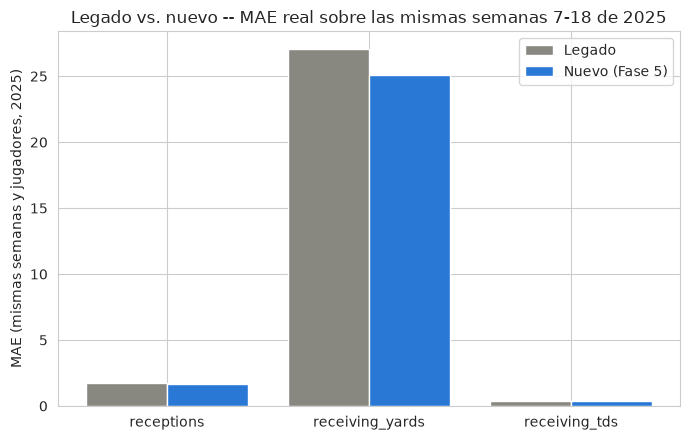

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(TARGETS))
ax.bar(x - 0.2, comparacion_final["legado_mae"], width=0.4, label="Legado", color=GRIS)
ax.bar(x + 0.2, comparacion_final["nuevo_mae"], width=0.4, label="Nuevo (Fase 5)", color=AZUL)
ax.set_xticks(x)
ax.set_xticklabels(TARGETS)
ax.set_ylabel("MAE (mismas semanas y jugadores, 2025)")
ax.set_title("Legado vs. nuevo -- MAE real sobre las mismas semanas 7-18 de 2025")
ax.legend()
plt.tight_layout()
plt.show()

## Cierre

**Mejora real en los 3 targets por MAE**, sobre las mismas semanas y los mismos jugadores que el
pipeline heredado ya predijo en su momento -- no una simulación aparte. En `receptions` y
`receiving_yards` la mejora es clara también en R² (0.26 vs 0.22, y 0.21 vs 0.12). En
`receiving_tds` el MAE mejora (0.34 vs 0.41) pero el R² del modelo nuevo es *más* negativo que el
del legado -- la misma tensión MAE-vs-R² ya documentada en `14_receiving_tds_modelos_de_conteo.ipynb`,
que se repite aquí de forma consistente, no es un caso aislado.

Respuesta directa a la pregunta que abrió esta fase: **sí, con todo lo construido en Fases 2-4 se
predice mejor que lo que ya se tenía reportado**, con la salvedad de `receiving_tds` documentada
explícitamente, no oculta.

Siguiente: [`17_explicabilidad_shap.ipynb`](17_explicabilidad_shap.ipynb).